In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import sys
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.sans-serif'] = ['Arial']


df = pd.read_csv('/Volumes/lab-windingm/home/users/cochral/LRS/AttractionRig/analysis/social-isolation/n10/grouped+isolated/probability_of_contact.csv')

# tracks 0-4 are socially isolated, 5-9 are group housed
df['focal_exp'] = np.where(df['focal_id'] <= 4, 'SI', 'GH')
df['other_exp'] = np.where(df['other_id'] <= 4, 'SI', 'GH')

# read focal-other: 'SI-GH' is an isolated larva approaching a group-housed one
df['condition'] = df['focal_exp'] + '-' + df['other_exp']


condition_order = ['SI-SI', 'SI-GH', 'GH-SI', 'GH-GH']

condition_colors = {
    'SI-SI': 'salmon',
    'SI-GH': 'lightsalmon',
    'GH-SI': 'lightsteelblue',
    'GH-GH': 'steelblue',
}

# only complete encounters: the larva came within 10 mm and left again
complete = df[df['end_reason'] == 'exit']

print(complete.groupby('condition').size())


condition
GH-GH    3178
GH-SI    3926
SI-GH    3921
SI-SI    3672
dtype: int64


    comparison  n_files    W        p significance
SI-GH vs SI-SI       12 10.0 0.020996            *
GH-SI vs GH-GH       12 22.0 0.203613           ns
SI-SI vs GH-GH       12  8.0 0.012207            *
SI-GH vs GH-SI       12 19.0 0.129395           ns
SI-SI vs GH-SI       12  8.0 0.012207            *
SI-GH vs GH-GH       12 19.0 0.129395           ns

           p_contact  n_files
condition                    
GH-GH          0.358       12
GH-SI          0.332       12
SI-GH          0.326       12
SI-SI          0.284       12


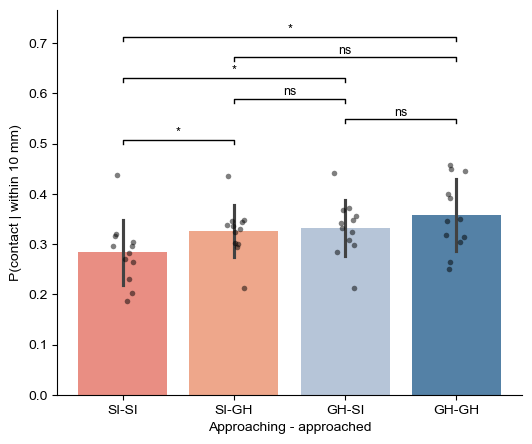

In [2]:
from scipy.stats import wilcoxon

# probability of contact per larva, then averaged per dish within each pairing
per_larva = (
    complete.groupby(['condition', 'file', 'focal_id'], as_index=False)
            .agg(p_contact=('contacted', 'mean'), n_encounters=('contacted', 'size'))
)

per_file = (
    per_larva.groupby(['condition', 'file'], as_index=False)
             .agg(p_contact=('p_contact', 'mean'), n_encounters=('n_encounters', 'mean'))
)

MEASURE = 'p_contact'

comparisons = [
    ('SI-GH', 'SI-SI'),
    ('GH-SI', 'GH-GH'),
    ('SI-SI', 'GH-GH'),
    ('SI-GH', 'GH-SI'),
    ('SI-SI', 'GH-SI'),
    ('SI-GH', 'GH-GH'),
]

# every dish contributes all four conditions, so compare them paired within dish
paired = per_file.pivot(index='file', columns='condition', values=MEASURE)

stats_rows = []

for test, reference in comparisons:

    both = paired[[test, reference]].dropna()
    stat, p_value = wilcoxon(both[test], both[reference])

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{test} vs {reference}',
        'test': test,
        'reference': reference,
        'n_files': len(both),
        'W': stat,
        'p': p_value,
        'significance': significance,
    })

print(pd.DataFrame(stats_rows)[['comparison', 'n_files', 'W', 'p', 'significance']].to_string(index=False))

print()
print(per_file.groupby('condition').agg(p_contact=('p_contact', 'mean'), n_files=('file', 'size')).round(3))

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=per_file,
    x='condition',
    y=MEASURE,
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

sns.stripplot(
    data=per_file,
    x='condition',
    y=MEASURE,
    order=condition_order,
    color='black',
    size=4,
    alpha=0.5,
    ax=ax,
)

# significance brackets, shortest span at the bottom
y_max = per_file[MEASURE].max()
step = y_max * 0.09

bracket_rows = sorted(
    stats_rows,
    key=lambda r: abs(condition_order.index(r['test']) - condition_order.index(r['reference']))
)

for level, row in enumerate(bracket_rows):
    x1 = condition_order.index(row['test'])
    x2 = condition_order.index(row['reference'])
    y = y_max + step * (level + 1)
    ax.plot([x1, x1, x2, x2], [y, y + step * 0.2, y + step * 0.2, y], lw=1, c='black')
    ax.text((x1 + x2) / 2, y + step * 0.25, row['significance'],
            ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, y_max + step * (len(bracket_rows) + 1.5))

plt.ylabel('P(contact | within 10 mm)')
plt.xlabel('Approaching - approached')
sns.despine()
plt.show()


condition  n_files   W        p significance
    SI-SI       12 0.0 0.000488          ***
    SI-GH       12 3.0 0.002441           **
    GH-SI       12 0.0 0.000488          ***
    GH-GH       12 1.0 0.000977          ***


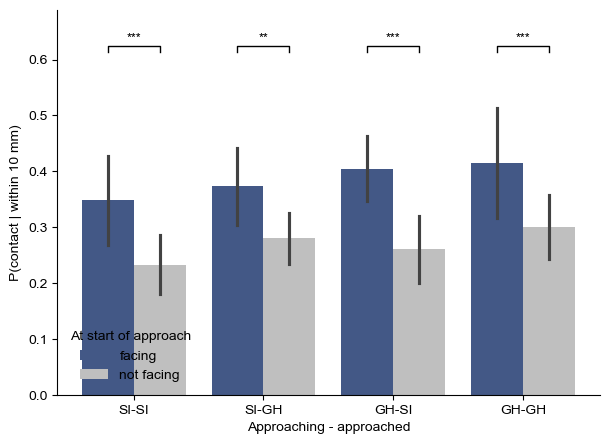

approach   facing  not facing
condition                    
GH-GH       0.415       0.300
GH-SI       0.405       0.261
SI-GH       0.373       0.280
SI-SI       0.348       0.233


In [3]:
# same thing, split by whether the larva was pointing at the other one at the start

per_larva_angle = (
    complete.groupby(['condition', 'file', 'focal_id', 'facing_at_start'], as_index=False)
            .agg(p_contact=('contacted', 'mean'), n_encounters=('contacted', 'size'))
)

per_file_angle = (
    per_larva_angle.groupby(['condition', 'file', 'facing_at_start'], as_index=False)
                   .agg(p_contact=('p_contact', 'mean'))
)

per_file_angle['approach'] = np.where(
    per_file_angle['facing_at_start'], 'facing', 'not facing'
)

# facing vs not facing, paired within dish, within each pairing
angle_rows = []

for condition in condition_order:

    subset = per_file_angle[per_file_angle['condition'] == condition]
    both = subset.pivot(index='file', columns='approach', values='p_contact').dropna()
    stat, p_value = wilcoxon(both['facing'], both['not facing'])

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    angle_rows.append({
        'condition': condition,
        'n_files': len(both),
        'W': stat,
        'p': p_value,
        'significance': significance,
    })

print(pd.DataFrame(angle_rows).to_string(index=False))

plt.figure(figsize=(7,5))

ax = sns.barplot(
    data=per_file_angle,
    x='condition',
    y='p_contact',
    order=condition_order,
    hue='approach',
    hue_order=['facing', 'not facing'],
    palette=['#385491', '#bfbfbf'],
    errorbar='sd',
)

# facing vs not facing bracket over each condition
y_max = per_file_angle['p_contact'].max()
step = y_max * 0.09

for row in angle_rows:
    x = condition_order.index(row['condition'])
    y = y_max + step
    ax.plot([x - 0.2, x - 0.2, x + 0.2, x + 0.2],
            [y, y + step * 0.2, y + step * 0.2, y], lw=1, c='black')
    ax.text(x, y + step * 0.25, row['significance'], ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, y_max + step * 2.5)

plt.ylabel('P(contact | within 10 mm)')
plt.xlabel('Approaching - approached')
plt.legend(title='At start of approach', frameon=False)
sns.despine()
plt.show()

print(per_file_angle.groupby(['condition', 'approach'])['p_contact'].mean().unstack().round(3))


    comparison  n_files    W        p significance
SI-GH vs SI-SI       12 21.0 0.176270           ns
GH-SI vs GH-GH       12  0.0 0.000488          ***
SI-SI vs GH-GH       12 21.0 0.176270           ns
SI-GH vs GH-SI       12 30.0 0.789675           ns
SI-SI vs GH-SI       12 16.0 0.130665           ns
SI-GH vs GH-GH       12  0.0 0.000488          ***


/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "
/Users/cochral/miniconda3/envs/maggots/lib/python3.8/site-packages/scipy/stats/_morestats.py:3414: UserWarning: Exact p-value calculation does not work if there are zeros. Switching to normal approximation.
  warnings.warn("Exact p-value calculation does not work if there are "


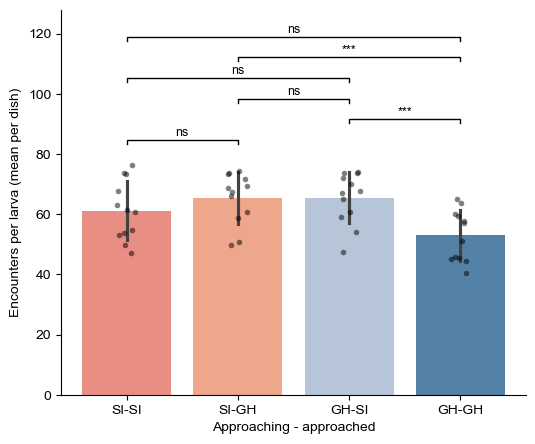

In [4]:
# how often they meet at all, so a difference in probability isn't confused with a difference in encounter rate

MEASURE = 'n_encounters'

comparisons = [
    ('SI-GH', 'SI-SI'),
    ('GH-SI', 'GH-GH'),
    ('SI-SI', 'GH-GH'),
    ('SI-GH', 'GH-SI'),
    ('SI-SI', 'GH-SI'),
    ('SI-GH', 'GH-GH'),
]

# every dish contributes all four conditions, so compare them paired within dish
paired = per_file.pivot(index='file', columns='condition', values=MEASURE)

stats_rows = []

for test, reference in comparisons:

    both = paired[[test, reference]].dropna()
    stat, p_value = wilcoxon(both[test], both[reference])

    if p_value < 0.001:
        significance = '***'
    elif p_value < 0.01:
        significance = '**'
    elif p_value < 0.05:
        significance = '*'
    else:
        significance = 'ns'

    stats_rows.append({
        'comparison': f'{test} vs {reference}',
        'test': test,
        'reference': reference,
        'n_files': len(both),
        'W': stat,
        'p': p_value,
        'significance': significance,
    })

print(pd.DataFrame(stats_rows)[['comparison', 'n_files', 'W', 'p', 'significance']].to_string(index=False))

plt.figure(figsize=(6,5))

ax = sns.barplot(
    data=per_file,
    x='condition',
    y=MEASURE,
    order=condition_order,
    hue='condition',
    hue_order=condition_order,
    palette=condition_colors,
    errorbar='sd',
    legend=False,
)

sns.stripplot(
    data=per_file,
    x='condition',
    y=MEASURE,
    order=condition_order,
    color='black',
    size=4,
    alpha=0.5,
    ax=ax,
)

# significance brackets, shortest span at the bottom
y_max = per_file[MEASURE].max()
step = y_max * 0.09

bracket_rows = sorted(
    stats_rows,
    key=lambda r: abs(condition_order.index(r['test']) - condition_order.index(r['reference']))
)

for level, row in enumerate(bracket_rows):
    x1 = condition_order.index(row['test'])
    x2 = condition_order.index(row['reference'])
    y = y_max + step * (level + 1)
    ax.plot([x1, x1, x2, x2], [y, y + step * 0.2, y + step * 0.2, y], lw=1, c='black')
    ax.text((x1 + x2) / 2, y + step * 0.25, row['significance'],
            ha='center', va='bottom', fontsize=9)

ax.set_ylim(0, y_max + step * (len(bracket_rows) + 1.5))

plt.ylabel('Encounters per larva (mean per dish)')
plt.xlabel('Approaching - approached')
sns.despine()
plt.show()
